In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

n, d = 100, 50

A = np.random.randn(n, d)
x_true = np.random.randn(d)

# make sparse true vector
x_true[np.abs(x_true) < 1.0] = 0

b = A @ x_true + 0.1 * np.random.randn(n)

In [3]:
def f(x):
    return 0.5 * np.linalg.norm(A @ x - b)**2

def grad_f(x):
    return A.T @ (A @ x - b)

def g(x, lam):
    return lam * np.linalg.norm(x, 1)

def objective(x, lam):
    return f(x) + g(x, lam)

def soft_threshold(z, thresh):
    return np.sign(z) * np.maximum(np.abs(z) - thresh, 0.0)

In [4]:
L = np.linalg.norm(A, 2)**2
eta = 1.0 / L

In [5]:
def ISTA(x0, lam, max_iter=100):
    x = x0.copy()
    history = []

    for _ in range(max_iter):
        x = soft_threshold(x - eta * grad_f(x), eta * lam)
        history.append(objective(x, lam))

    return x, history

In [6]:
def FISTA(x0, lam, max_iter=100):
    x = x0.copy()
    y = x0.copy()
    t = 1

    history = []

    for _ in range(max_iter):
        x_new = soft_threshold(y - eta * grad_f(y), eta * lam)

        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        y = x_new + ((t - 1) / t_new) * (x_new - x)

        x = x_new
        t = t_new

        history.append(objective(x, lam))

    return x, history

In [7]:
x0 = np.zeros(d)
lam = 0.1

x_ista, hist_ista = ISTA(x0, lam, max_iter=100)
x_fista, hist_fista = FISTA(x0, lam, max_iter=100)

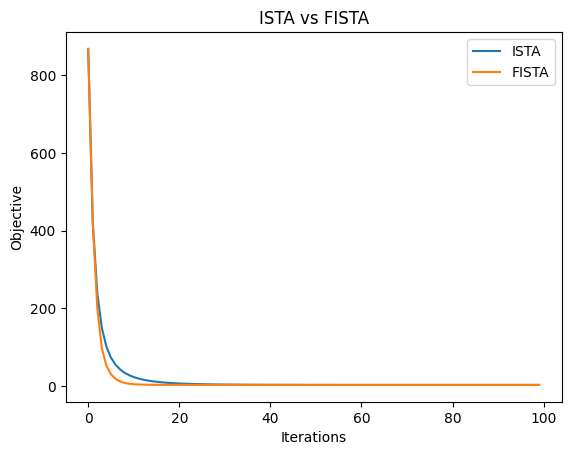

In [8]:
plt.plot(hist_ista, label="ISTA")
plt.plot(hist_fista, label="FISTA")
plt.xlabel("Iterations")
plt.ylabel("Objective")
plt.title("ISTA vs FISTA")
plt.legend()
plt.show()

In [9]:
print("True sparsity:", np.sum(x_true == 0))
print("ISTA sparsity:", np.sum(x_ista == 0))
print("FISTA sparsity:", np.sum(x_fista == 0))

True sparsity: 30
ISTA sparsity: 5
FISTA sparsity: 5


we don’t know 
𝐿, so adapt step size

In [10]:
def FISTA_backtracking(x0, lam, max_iter=100, L0=1.0, beta=2.0):
    x = x0.copy()
    y = x0.copy()
    t = 1
    L = L0

    history = []

    for _ in range(max_iter):
        while True:
            eta = 1.0 / L
            x_new = soft_threshold(y - eta * grad_f(y), eta * lam)

            # check descent condition
            lhs = f(x_new)
            rhs = f(y) + grad_f(y).T @ (x_new - y) + (L/2) * np.linalg.norm(x_new - y)**2

            if lhs <= rhs:
                break
            L *= beta  # increase L

        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        y = x_new + ((t - 1) / t_new) * (x_new - x)

        x = x_new
        t = t_new

        history.append(objective(x, lam))

    return x, history

In [11]:
def FISTA_restart(x0, lam, max_iter=100):
    x = x0.copy()
    y = x0.copy()
    t = 1

    history = []

    for _ in range(max_iter):
        x_new = soft_threshold(y - eta * grad_f(y), eta * lam)

        # restart condition (gradient mapping)
        if np.dot(x_new - x, y - x_new) > 0:
            y = x.copy()
            t = 1
        else:
            t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
            y = x_new + ((t - 1) / t_new) * (x_new - x)
            t = t_new

        x = x_new
        history.append(objective(x, lam))

    return x, history

In [12]:
x_bt, hist_bt = FISTA_backtracking(x0, lam)
x_rs, hist_rs = FISTA_restart(x0, lam)

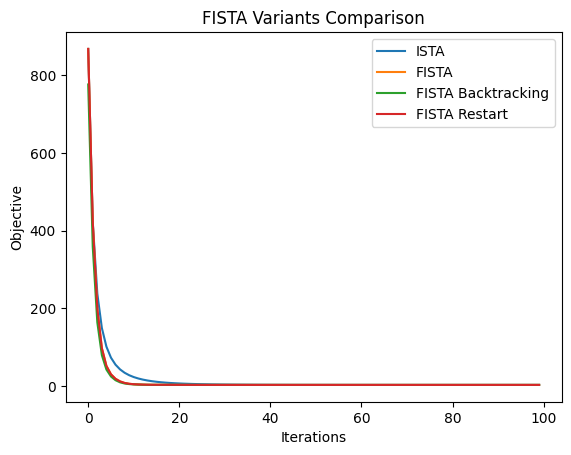

In [13]:
plt.plot(hist_ista, label="ISTA")
plt.plot(hist_fista, label="FISTA")
plt.plot(hist_bt, label="FISTA Backtracking")
plt.plot(hist_rs, label="FISTA Restart")

plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Objective")
plt.title("FISTA Variants Comparison")
plt.show()

In [14]:
def ADMM_lasso(x0, lam, rho=1.0, max_iter=100):
    x = x0.copy()
    z = x0.copy()
    u = np.zeros_like(x0)

    history = []

    AtA = A.T @ A
    Atb = A.T @ b

    # precompute
    M = np.linalg.inv(AtA + rho * np.eye(d))

    for _ in range(max_iter):
        # x-update (quadratic solve)
        x = M @ (Atb + rho * (z - u))

        # z-update (prox)
        z = soft_threshold(x + u, lam / rho)

        # dual update
        u = u + (x - z)

        history.append(objective(x, lam))

    return x, history

In [15]:
x_admm, hist_admm = ADMM_lasso(x0, lam)

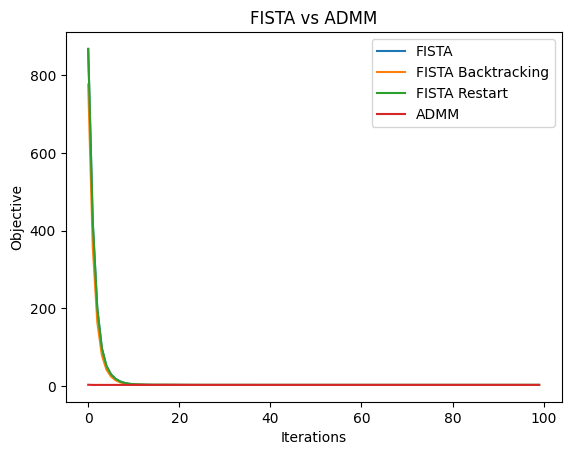

In [16]:
plt.plot(hist_fista, label="FISTA")
plt.plot(hist_bt, label="FISTA Backtracking")
plt.plot(hist_rs, label="FISTA Restart")
plt.plot(hist_admm, label="ADMM")

plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Objective")
plt.title("FISTA vs ADMM")
plt.show()